17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/5


C:\Users\MCA-Lab6\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


704/704 ━━━━━━━━━━━━━━━━━━━━ 116s 160ms/step - accuracy: 0.7882 - loss: 0.4444 - val_accuracy: 0.8340 - val_loss: 0.3756
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.8889 - loss: 0.2716 - val_accuracy: 0.8500 - val_loss: 0.3550
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 217ms/step - accuracy: 0.9263 - loss: 0.1914 - val_accuracy: 0.8312 - val_loss: 0.3799
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 161ms/step - accuracy: 0.9487 - loss: 0.1420 - val_accuracy: 0.8320 - val_loss: 0.4201
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 160ms/step - accuracy: 0.9672 - loss: 0.0935 - val_accuracy: 0.8340 - val_loss: 0.5477
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.8396 - loss: 0.5459
Test Accuracy: 0.8396000266075134


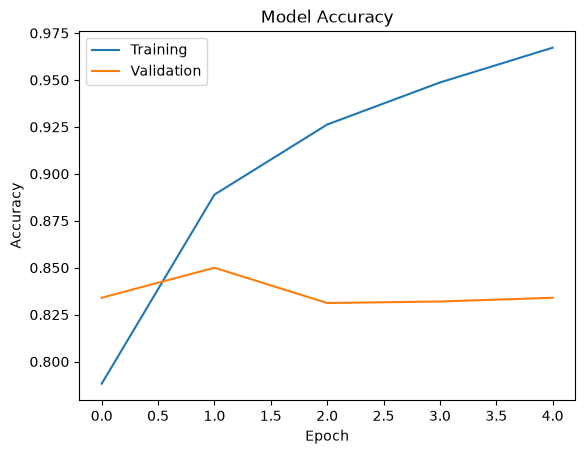

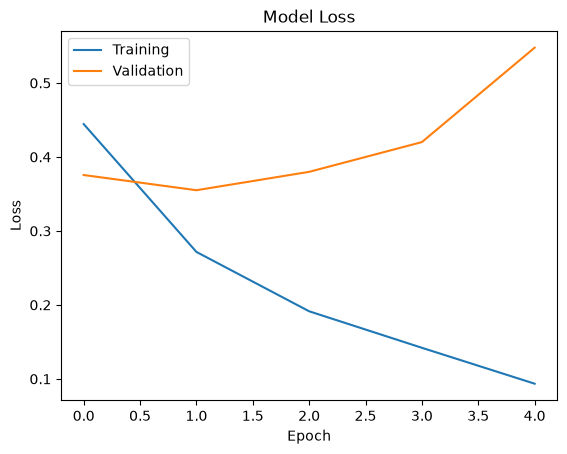

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt

max_features = 10000
maxlen = 100

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

model = models.Sequential([
    layers.Embedding(max_features, 128, input_length=maxlen),
    layers.LSTM(128),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])
plt.title("Model Loss")
plt.show()